In [1]:
## 1. Importación de librerías

In [4]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 294 kB 2.1 MB/s eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuración general de estilo
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [6]:
## 2. Carga y exploración de datos

In [7]:
CSV_PATH = 'data/share-of-population-in-extreme-poverty/share-of-population-in-extreme-poverty.csv'
POVERTY_COL = 'Share of population in poverty ($3 a day)'

df = pd.read_csv(CSV_PATH)

print(f'Filas totales : {len(df):,}')
print(f'Columnas      : {df.columns.tolist()}')
print(f'Rango de años : {df["Year"].min()} – {df["Year"].max()}')
df.head()

Filas totales : 59,371
Columnas      : ['Entity', 'Code', 'Year', 'Share of population in poverty ($3 a day)', 'Population', 'World region according to OWID']
Rango de años : -10000 – 2026


,Entity,Code,Year,Share of population in poverty ($3 a day),Population,World region according to OWID
0,Afghanistan,AFG,-10000,NaN,14737.0,Asia
1,Afghanistan,AFG,-9000,NaN,20405.0,Asia
2,Afghanistan,AFG,-8000,NaN,28253.0,Asia
3,Afghanistan,AFG,-7000,NaN,39120.0,Asia
4,Afghanistan,AFG,-6000,NaN,54166.0,Asia


In [8]:
## 3. Limpieza y filtrado de datos

In [9]:
# Año de referencia: el más reciente con buena cobertura de países
REFERENCE_YEAR = 2022
TOP_N = 20  # Número de países a mostrar

# Filtramos solo países (Code ISO-3 de 3 letras) y el año de referencia
df_year = (
    df[
        (df['Year'] == REFERENCE_YEAR) &
        (df['Code'].str.len() == 3) &
        (df[POVERTY_COL].notna())
    ]
    .copy()
)

# Top N países con mayor pobreza extrema
top_countries = (
    df_year
    .nlargest(TOP_N, POVERTY_COL)
    [['Entity', POVERTY_COL, 'World region according to OWID', 'Population']]
    .reset_index(drop=True)
)

top_countries.index += 1  # ranking desde 1
print(f'✅ Top {TOP_N} países con mayor pobreza extrema en {REFERENCE_YEAR}:')
top_countries

✅ Top 20 países con mayor pobreza extrema en 2022:


,Entity,Share of population in poverty ($3 a day),World region according to OWID,Population
1,Mozambique,81.361377,Africa,3.265624e+07
2,Zambia,71.656150,Africa,2.015294e+07
3,Kenya,45.482665,Africa,5.425246e+07
4,Nigeria,41.819549,Africa,2.231509e+08
5,Chad,39.475375,Africa,1.845532e+07
6,Syria,17.961851,Asia,2.246217e+07
7,South Africa,17.435920,Africa,6.237842e+07
8,Colombia,9.266202,South America,5.173794e+07
9,Tajikistan,8.852836,Asia,1.018223e+07
10,Equatorial Guinea,8.794199,Africa,1.803549e+06


In [10]:
## 4. Gráfico de barras horizontal — Top 20 países

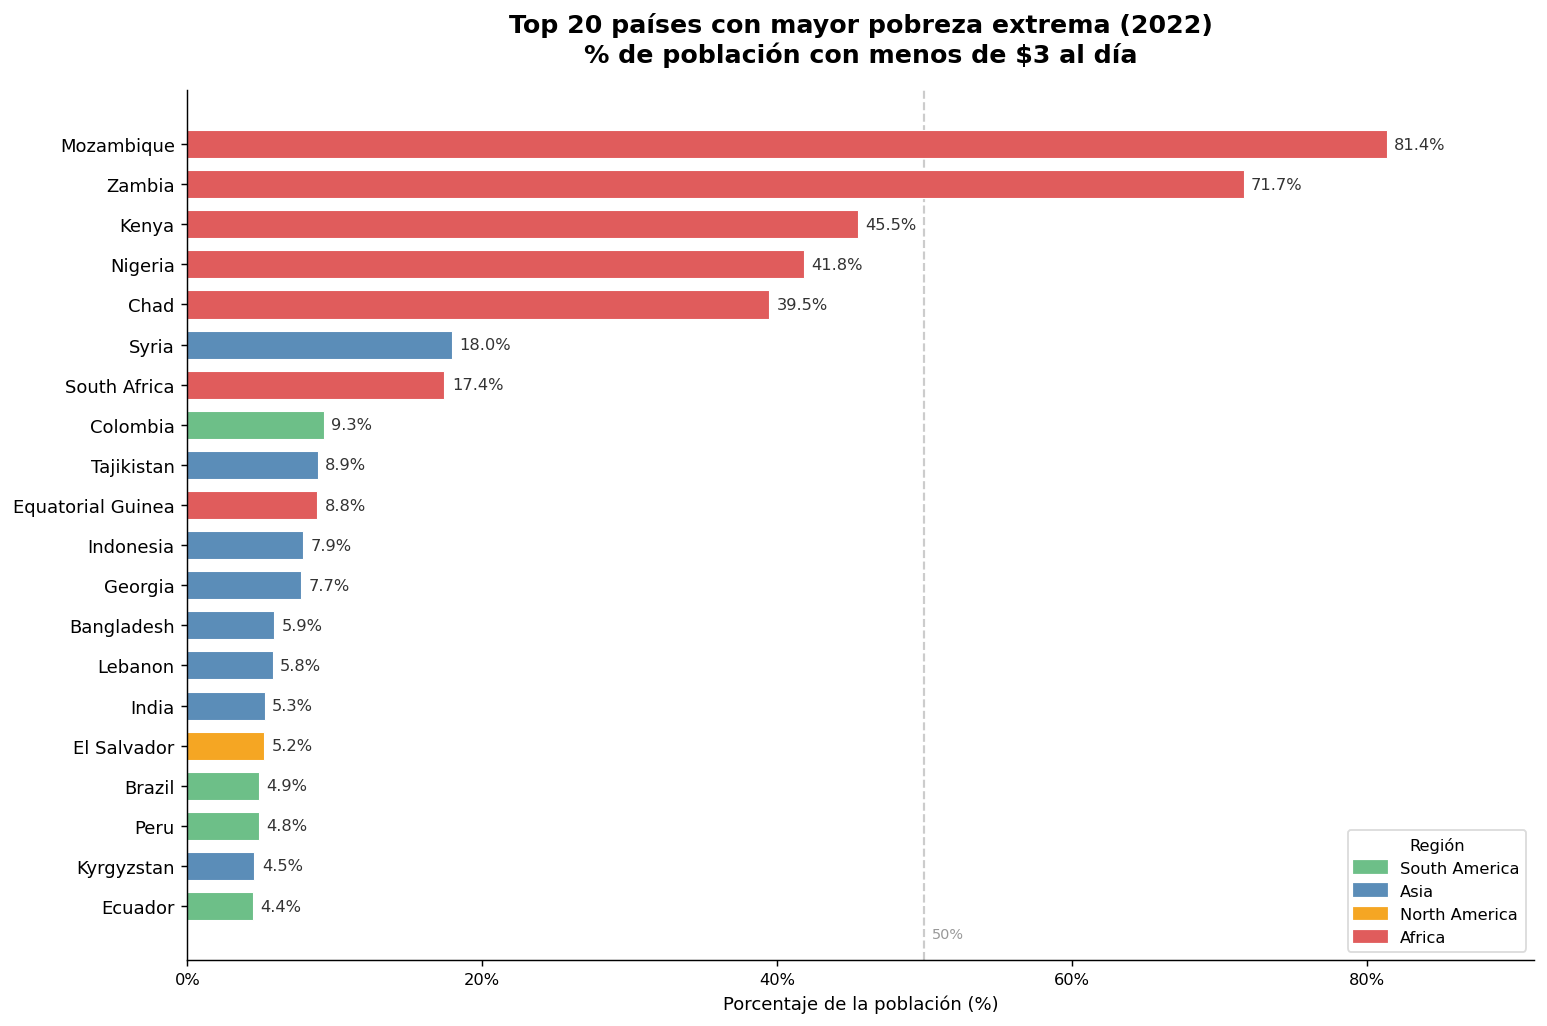

✅ Gráfico guardado como pobreza_top20_barras.png


In [11]:
# Paleta de colores por región
REGION_COLORS = {
    'Africa'        : '#E05C5C',
    'Asia'          : '#5B8DB8',
    'South America' : '#6DBF88',
    'North America' : '#F5A623',
    'Europe'        : '#9B59B6',
    'Oceania'       : '#1ABC9C',
}
DEFAULT_COLOR = '#AAAAAA'

# Ordenar ascendente para que el mayor quede arriba
plot_data = top_countries.sort_values(POVERTY_COL, ascending=True).reset_index(drop=True)
regions   = plot_data['World region according to OWID']
colors    = [REGION_COLORS.get(r, DEFAULT_COLOR) for r in regions]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    plot_data['Entity'],
    plot_data[POVERTY_COL],
    color=colors,
    edgecolor='white',
    linewidth=0.6,
    height=0.7
)

# Etiquetas de valor al final de cada barra
for bar, val in zip(bars, plot_data[POVERTY_COL]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center', ha='left',
        fontsize=9, color='#333333'
    )

# Línea de referencia en 50%
ax.axvline(50, color='#CCCCCC', linewidth=1.2, linestyle='--', zorder=0)
ax.text(50.5, -0.8, '50%', fontsize=8, color='#999999')

# Eje X
ax.set_xlim(0, max(plot_data[POVERTY_COL]) + 10)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=10)

# Leyenda de regiones
used_regions = regions.unique()
handles = [
    plt.Rectangle((0, 0), 1, 1, color=REGION_COLORS.get(r, DEFAULT_COLOR))
    for r in used_regions
]
ax.legend(handles, used_regions, title='Región', loc='lower right',
          fontsize=9, title_fontsize=9, framealpha=0.7)

# Títulos
ax.set_title(
    f'Top {TOP_N} países con mayor pobreza extrema ({REFERENCE_YEAR})\n'
    '% de población con menos de $3 al día',
    fontsize=14, fontweight='bold', pad=16
)
ax.set_xlabel('Porcentaje de la población (%)', fontsize=10)

plt.tight_layout()
plt.savefig('pobreza_top20_barras.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gráfico guardado como pobreza_top20_barras.png')